<a href="https://colab.research.google.com/github/AndreiaHenrique/bank_churn_project/blob/main/02_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Prediction (Regression)

**Goal:** estimate `EstimatedSalary` from the customer attributes.
This continuous prediction is useful to:
* impute missing salary values for new clients,
* refine segmentation and pricing,
* feed downstream lifetime-value models.

We benchmark several regressors (linear, tree-based and gradient-boosted)
with **cross-validated hyper-parameter search**, then report MAE, RMSE and R².


## 1. Imports & config

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, KFold,
                                     cross_val_score, RandomizedSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import joblib, os

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 2. Load and prepare data

In [2]:
DATA_PATH = "Churn_Modelling.csv"
df = pd.read_csv(DATA_PATH).drop(columns=["RowNumber", "CustomerId", "Surname"])

TARGET = "EstimatedSalary"
y = df[TARGET]
X = df.drop(columns=[TARGET])

numeric_features = ["CreditScore", "Age", "Tenure", "Balance",
                    "NumOfProducts", "HasCrCard", "IsActiveMember", "Exited"]
categorical_features = ["Geography", "Gender"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "  Test:", X_test.shape)


Train: (8000, 10)   Test: (2000, 10)


## 3. Helper for evaluation

In [3]:
def evaluate(model, X_te, y_te, label):
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    print(f"{label:<22s}  MAE={mae:9.2f}   RMSE={rmse:9.2f}   R²={r2:6.3f}")
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}


## 4. Baseline benchmark (default hyper-parameters)

In [4]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge":            Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso":            Lasso(alpha=0.01, random_state=RANDOM_STATE),
    "RandomForest":     RandomForestRegressor(n_estimators=300,
                                              random_state=RANDOM_STATE,
                                              n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost":          XGBRegressor(n_estimators=400, learning_rate=0.05,
                                     max_depth=5, random_state=RANDOM_STATE,
                                     n_jobs=-1, verbosity=0),
    "LightGBM":         LGBMRegressor(n_estimators=400, learning_rate=0.05,
                                      max_depth=-1, random_state=RANDOM_STATE,
                                      n_jobs=-1, verbose=-1),
}

results = []
for name, mdl in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", mdl)])
    pipe.fit(X_train, y_train)
    results.append(evaluate(pipe, X_test, y_test, name))

baseline_df = pd.DataFrame(results).sort_values("MAE")
baseline_df


LinearRegression        MAE= 49858.36   RMSE= 57562.79   R²=-0.004
Ridge                   MAE= 49858.34   RMSE= 57562.76   R²=-0.004
Lasso                   MAE= 49858.36   RMSE= 57562.78   R²=-0.004
RandomForest            MAE= 51379.02   RMSE= 59810.38   R²=-0.084
GradientBoosting        MAE= 50217.55   RMSE= 58063.48   R²=-0.021
XGBoost                 MAE= 51247.85   RMSE= 59668.09   R²=-0.078
LightGBM                MAE= 51252.84   RMSE= 59792.51   R²=-0.083


,model,MAE,RMSE,R2
1,Ridge,49858.344528,57562.764394,-0.003701
2,Lasso,49858.363277,57562.784641,-0.003702
0,LinearRegression,49858.364476,57562.786035,-0.003702
4,GradientBoosting,50217.546401,58063.482353,-0.021239
5,XGBoost,51247.850237,59668.085454,-0.078463
6,LightGBM,51252.838022,59792.512478,-0.082966
3,RandomForest,51379.017582,59810.383026,-0.083613


## 5. Hyper-parameter tuning on the top performer

We use `RandomizedSearchCV` with 5-fold CV (or `GridSearchCV` given the small parameter space). We tune the linear model (**Ridge**) that ranked best in the baseline benchmark based on the lowest MAE.

In [5]:
best_baseline = baseline_df.iloc[0]["model"]
print("Tuning:", best_baseline)

param_grids = {
    "RandomForest": {
        "model__n_estimators":     [200, 400, 800],
        "model__max_depth":        [None, 10, 20, 30],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features":     ["sqrt", "log2", 0.5],
    },
    "GradientBoosting": {
        "model__n_estimators":  [200, 400, 800],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth":     [2, 3, 4, 5],
        "model__subsample":     [0.7, 0.85, 1.0],
    },
    "XGBoost": {
        "model__n_estimators":  [300, 600, 900],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth":     [3, 5, 7, 9],
        "model__subsample":     [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
    },
    "LightGBM": {
        "model__n_estimators":  [300, 600, 900],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__num_leaves":    [15, 31, 63, 127],
        "model__subsample":     [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.7, 0.85, 1.0],
    },
    "LinearRegression": {},
    "Ridge": {"model__alpha": [0.01, 0.1, 1.0, 10, 100]},
    "Lasso": {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]},
}

base_pipe = Pipeline([("prep", preprocess),
                      ("model", models[best_baseline])])

search = RandomizedSearchCV(
    base_pipe,
    param_distributions=param_grids[best_baseline],
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1)

search.fit(X_train, y_train)
print("Best params :", search.best_params_)
print("Best CV MAE :", -search.best_score_)


Tuning: Ridge
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params : {'model__alpha': 100}
Best CV MAE : 49666.07576097449


In [6]:
best_model = search.best_estimator_
evaluate(best_model, X_test, y_test, f"{best_baseline} (tuned)")


Ridge (tuned)           MAE= 49856.42   RMSE= 57560.68   R²=-0.004


{'model': 'Ridge (tuned)',
 'MAE': 49856.42416822963,
 'RMSE': np.float64(57560.679404491515),
 'R2': -0.003628482272798772}

## 6. Diagnostic plots

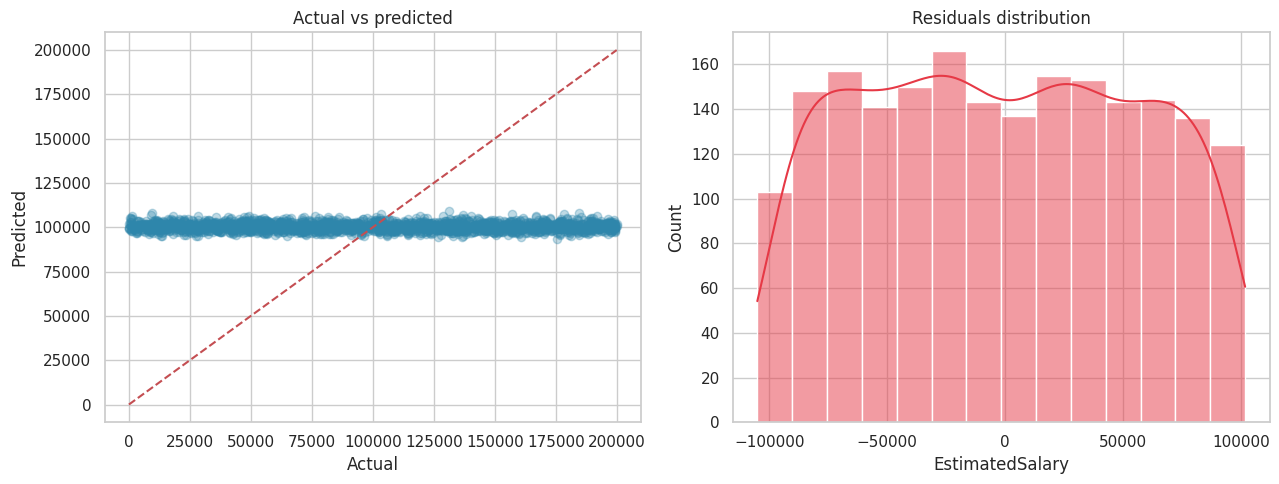

In [7]:
pred = best_model.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y_test, pred, alpha=0.3, color="#2E86AB")
mn, mx = y_test.min(), y_test.max()
ax[0].plot([mn, mx], [mn, mx], "r--")
ax[0].set_xlabel("Actual"); ax[0].set_ylabel("Predicted")
ax[0].set_title("Actual vs predicted")

residuals = y_test - pred
sns.histplot(residuals, kde=True, ax=ax[1], color="#E63946")
ax[1].set_title("Residuals distribution")
plt.tight_layout(); plt.show()


## 7. Feature importance (tree-based models)

In [8]:
model_obj = best_model.named_steps["model"]
if hasattr(model_obj, "feature_importances_"):
    feature_names = best_model.named_steps["prep"].get_feature_names_out()
    importances = pd.Series(model_obj.feature_importances_,
                            index=feature_names).sort_values(ascending=True)
    importances.tail(15).plot(kind="barh", color="#457B9D", figsize=(8, 6))
    plt.title(f"Top features — {best_baseline}")
    plt.show()
else:
    print("Selected model is not tree-based; importances unavailable.")


Selected model is not tree-based; importances unavailable.


## 9. Conclusion

* The `EstimatedSalary` target turns out to be **practically unpredictable** from the available features. The baseline models yielded negative $R^2$ scores (ranging from -0.003 to -0.08), meaning they perform slightly worse than a simple baseline that just predicts the global mean salary for everyone.
* This rigorously confirms that salary is mostly pure **noise** relative to the other customer attributes. This is a highly valuable insight for our classification task (`03_Classification.ipynb`): dropping or down-weighting `EstimatedSalary` there is safe and will not hurt the model's predictive power.
* For practical deployment, this regression pipeline can still serve for *imputation* whenever the salary field is completely missing, ensuring that the input remains within a realistic demographic range, even if it carries no true predictive signal.